In [7]:
import numpy as np

#parameters
A = 1
Delta = 1   #topological
Nk = 101

kx = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

#hamiltonian
def H(kx, ky):
    hx = A*np.sin(kx)
    hy = A*np.sin(ky)
    hz = Delta + np.cos(kx) + np.cos(ky)
    return np.array([
        [hz, hx - 1j*hy],
        [hx + 1j*hy, -hz]
    ], dtype=complex)

#eigenvectos
u = np.zeros((Nk, Nk, 2), dtype=complex)
for ix in range(Nk):
    for iy in range(Nk):
        w, v = np.linalg.eigh(H(kx[ix], ky[iy]))
        u[ix, iy] = v[:, 0]   # lower band
def link(a, b):
    return np.vdot(a, b) / np.abs(np.vdot(a, b))

chern = 0.0

for ix in range(Nk):
    for iy in range(Nk):
        u00 = u[ix, iy]
        u10 = u[(ix+1)%Nk, iy]
        u01 = u[ix, (iy+1)%Nk]
        u11 = u[(ix+1)%Nk, (iy+1)%Nk]

        Ux = link(u00, u10)
        Uy = link(u00, u01)
        Ux_y = link(u01, u11)
        Uy_x = link(u10, u11)

        F = np.log(Ux * Uy_x / (Ux_y * Uy))
        chern += F.imag

chern /= (2*np.pi)

print("Chern number =", round(chern, 2))

Chern number = 1.0


Computing k-points: 100%|██████████| 10000/10000 [1:56:32<00:00,  1.43it/s]


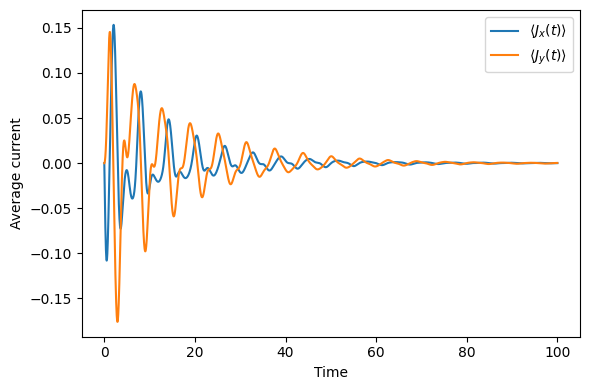

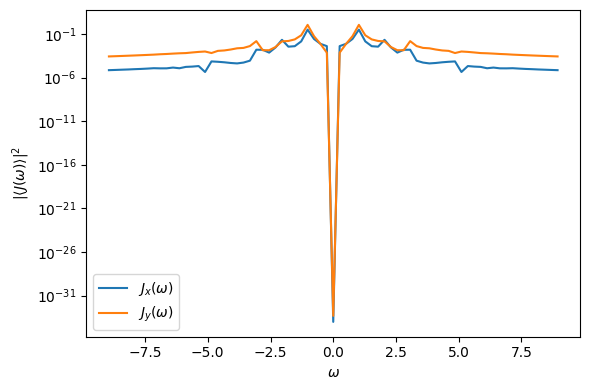

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from tqdm import tqdm

#paramaters 
Nk = 100
Delta = 1.0
A0 = 0.6           
omega = 1.0
T = 2 * np.pi / omega
t_final = 100.0
Nt = 12000
t_eval = np.linspace(0, t_final, Nt)
gamma = 0.03      
eta = 0.08        

#pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)

#hamiltonian 
def h_vec(kx, ky):
    return np.array([
        np.sin(kx),
        np.sin(ky),
        Delta + np.cos(kx) + np.cos(ky)
    ])
def H(kx, ky):
    hx, hy, hz = h_vec(kx, ky)
    return hx * sx + hy * sy + hz * sz
def H_t(t, kx, ky):
    return H(kx + A0 * np.sin(omega * t), ky)

#current operators 
def jx(t, kx):
    return (
        np.cos(kx + A0 * np.sin(omega * t)) * sx
        - np.sin(kx + A0 * np.sin(omega * t)) * sz
    )

def jy(ky):
    return np.cos(ky) * sy - np.sin(ky) * sz

#schrodinger
def schrodinger_band(t, psi, kx, ky, U):
    H_band = U.conj().T @ H_t(t, kx, ky) @ U
    return -1j * H_band @ psi - gamma * psi

#k-grid
kvals = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
Jx_t = np.zeros(Nt)
Jy_t = np.zeros(Nt)
total_k = Nk * Nk

#main loop
with tqdm(total=total_k, desc="Computing k-points") as pbar:
    for kx in kvals:
        for ky in kvals:
            H0 = H(kx, ky)
            evals, U = np.linalg.eigh(H0)
            psi0 = np.array([0.0, 1.0], dtype=complex)
            sol = solve_ivp(
                schrodinger_band,
                (0, t_final),
                psi0,
                t_eval=t_eval,
                args=(kx, ky, U),
                rtol=1e-7,
                atol=1e-9,)
            psi_t = sol.y.T
            norms = np.linalg.norm(psi_t, axis=1, keepdims=True)
            psi_t = psi_t * (1 + eta * (1 - norms))

            #current
            for i, (t, psi) in enumerate(zip(t_eval, psi_t)):
                jx_band = U.conj().T @ jx(t, kx) @ U
                jy_band = U.conj().T @ jy(ky) @ U

                Jx_t[i] += np.real(np.vdot(psi, jx_band @ psi))
                Jy_t[i] += np.real(np.vdot(psi, jy_band @ psi))

            pbar.update(1)

#bz average
Jx_t /= Nk**2
Jy_t /= Nk**2

Jx_t -= np.mean(Jx_t[-1000:])
Jy_t -= np.mean(Jy_t[-1000:])

plt.figure(figsize=(6,4))
plt.plot(t_eval, Jx_t, label=r'$\langle J_x(t)\rangle$')
plt.plot(t_eval, Jy_t, label=r'$\langle J_y(t)\rangle$')
plt.xlabel("Time")
plt.ylabel("Average current")
plt.legend()
plt.tight_layout()
plt.show()

#fft from last periods
N_periods_fft = 3
n_total_periods = int(t_final / T)
t_start_fft = (n_total_periods - N_periods_fft) * T

mask_last = t_eval >= t_start_fft
t_fft = t_eval[mask_last]

Jx_window = Jx_t[mask_last] - np.mean(Jx_t[mask_last])
Jy_window = Jy_t[mask_last] - np.mean(Jy_t[mask_last])

dt = t_fft[1] - t_fft[0]

freqs = fftshift(fftfreq(len(t_fft), dt)) * 2*np.pi
Jx_fft = fftshift(np.abs(fft(Jx_window))**2)
Jy_fft = fftshift(np.abs(fft(Jy_window))**2)

freq_mask = np.abs(freqs) <= 9

plt.figure(figsize=(6,4))
plt.semilogy(freqs[freq_mask], Jx_fft[freq_mask], label=r'$J_x(\omega)$')
plt.semilogy(freqs[freq_mask], Jy_fft[freq_mask], label=r'$J_y(\omega)$')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|\langle J(\omega)\rangle|^2$')
plt.legend()
plt.tight_layout()
plt.show()